**25/12/2025**

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

tips = sns.load_dataset('tips')
tips.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [13]:
# simple, manual label encoding using map method
tips['smoker_bin'] = tips['smoker'].map({
    'Yes': 1,
    'No' : 0}
)

tips['sex_bin'] = tips['sex'].map({
    'Male': 1,
    'Female' : 0}
)

tips.head(2)

,total_bill,tip,sex,smoker,day,time,size,smoker_bin,sex_bin
0,16.99,1.01,Female,No,Sun,Dinner,2,0,0
1,10.34,1.66,Male,No,Sun,Dinner,3,0,1


In [14]:
# X = tips[['smoker_bin']] # 0101011101110101
y = tips['tip'] # continous

# convert the target column, then use it for y

X = tips[['total_bill']] 
y = tips['sex_bin'] # encoded column

# yes, how much did they tip?
# are we predicting a continous value?

In [15]:
model_dt = DecisionTreeClassifier() # classification
model_lr = LogisticRegression()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state= 42, test_size=0.2)

model_dt.fit(X_train, y_train) # fitting here, must be numeric
model_lr.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
y_pred_lr = model_lr.predict(X_test)

In [19]:
cr_dt = classification_report(y_test,y_pred_dt)

cr_lr = classification_report(y_test,y_pred_lr)
print(cr_dt,cr_lr)

              precision    recall  f1-score   support

           0       0.48      0.58      0.52        19
           1       0.69      0.60      0.64        30

    accuracy                           0.59        49
   macro avg       0.59      0.59      0.58        49
weighted avg       0.61      0.59      0.60        49
               precision    recall  f1-score   support

           0       1.00      0.05      0.10        19
           1       0.62      1.00      0.77        30

    accuracy                           0.63        49
   macro avg       0.81      0.53      0.43        49
weighted avg       0.77      0.63      0.51        49



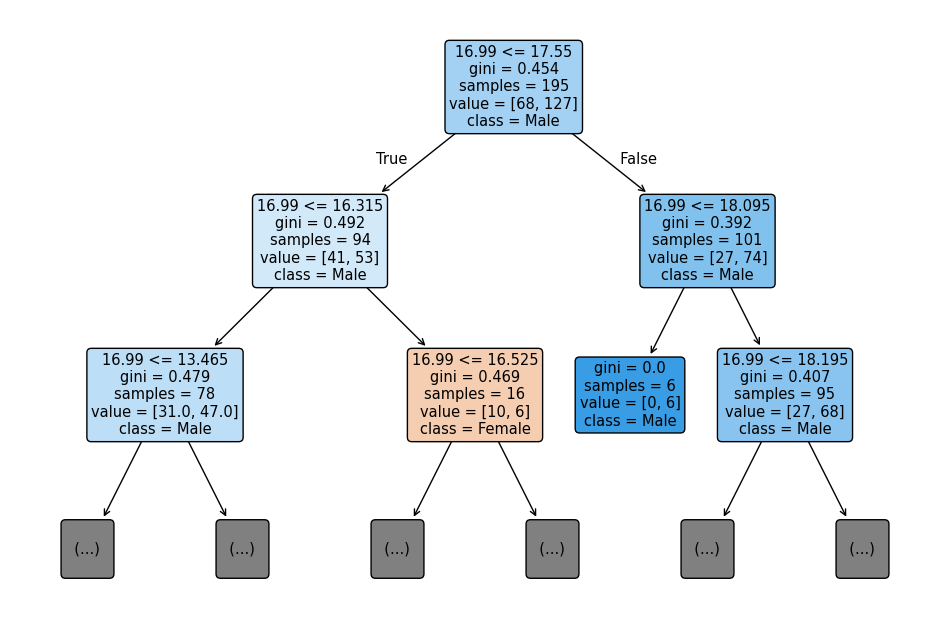

In [17]:
plt.figure(figsize=(12,8))

plot_tree(
    model_dt,
    feature_names=tips['total_bill'],   #SNAS: input features. multiple input features if you want
    class_names=tips['sex'],    #SNAS: target name
    max_depth=2,
    filled=True,
    rounded=True
)
plt.show()

In [ ]:
#SNAS:
#the first box on top of the tree is the root node
#gini, sample